In [301]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [302]:
df_processed = pd.read_pickle("dataframes/df_processed.pkl")

crime_codes = {
    'ICCS0101': 'Intentional homicide',
    'ICCS0301': 'Sexual violence',
    'ICCS03011': 'Rape',
    'ICCS0401': 'Robbery',
    'ICCS0502': 'Theft',
}

In [303]:
df_cluster = df_processed.groupby('country')[['asylum_per_100k', 'crime_per_100k']].mean()

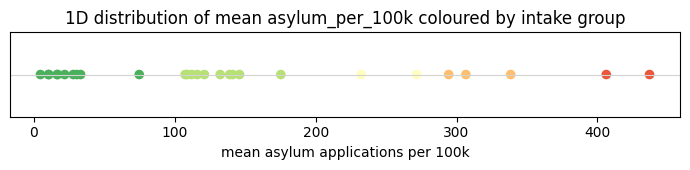

In [304]:
# 1. Cluster countries by mean asylum applications per 100k (5 ordered clusters)

# Use df_cluster computed above: mean asylum_per_100k per country
scaler_asylum = StandardScaler()
X_asylum = scaler_asylum.fit_transform(df_cluster[['asylum_per_100k']])

k = 5
kmeans_asylum = KMeans(n_clusters=k, random_state=42)
df_cluster['cluster_asylum_raw'] = kmeans_asylum.fit_predict(X_asylum)

# Reorder labels so 0 = lowest mean asylum_per_100k, 4 = highest
means_asylum = (
    df_cluster
    .groupby('cluster_asylum_raw')['asylum_per_100k']
    .mean()
    .sort_values()
 )
label_map_asylum = {old: new for new, old in enumerate(means_asylum.index)}
df_cluster['cluster_asylum'] = df_cluster['cluster_asylum_raw'].map(label_map_asylum)

# Verbose group labels for clusters
label_map_verbose = {
    0: '0 - low',
    1: '1 - medium low',
    2: '2 - medium',
    3: '3 - medium high',
    4: '4 - high',
}
df_cluster['cluster_group'] = df_cluster['cluster_asylum'].map(label_map_verbose)

# 1D axis plot: each country as a dot at its mean asylum_per_100k, coloured by cluster
base_palette = sns.color_palette('RdYlGn_r', 5)
cluster_colors = {i: base_palette[i] for i in range(5)}

df_plot = df_cluster.reset_index()
x_vals = df_plot['asylum_per_100k']
y_vals = [0] * len(df_plot)
colors = df_plot['cluster_asylum'].map(cluster_colors)

fig, ax = plt.subplots(figsize=(7, 1.8))
ax.scatter(x_vals, y_vals, c=colors, s=35)

# Draw a thin horizontal axis line
ax.axhline(0, color='lightgrey', linewidth=0.8)

# Hide y-axis
ax.set_yticks([])
ax.set_ylabel("")
ax.set_xlabel('mean asylum applications per 100k')
ax.set_title('1D distribution of mean asylum_per_100k coloured by intake group')
plt.tight_layout()
plt.show()

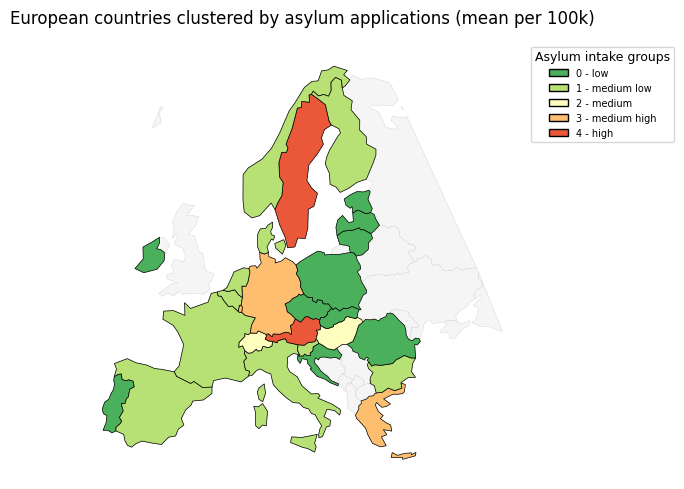

In [305]:
# 2. Plot map of Europe coloured by asylum clusters (green → red)

import geopandas as gpd
from shapely.geometry import box
from matplotlib.patches import Patch
import seaborn as sns

# URL to Natural Earth admin-0 countries (110m resolution)
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"

# Load world country borders and filter to Europe
world = gpd.read_file(url)
europe = world[world["CONTINENT"] == "Europe"].copy()

# Define Europe bounding box (lon/lat) and clip geometries
europe_bbox = box(-15, 30, 40, 72)
europe = gpd.clip(europe, europe_bbox)

# Merge cluster data (one row per country)
df_cluster_reset = df_cluster.reset_index()
gdf = europe.merge(
    df_cluster_reset,
    left_on="NAME",
    right_on="country",
    how="left"
 )

# Reproject to a Europe-friendly projected CRS (ETRS89 / LAEA Europe)
gdf_laea = gdf.to_crs(epsg=3035)

# Base palette: green (low) → yellow → red (high)
base_palette = sns.color_palette('RdYlGn_r', 5)
cluster_colors = {i: base_palette[i] for i in range(5)}
label_map_verbose = {
    0: '0 - low',
    1: '1 - medium low',
    2: '2 - medium',
    3: '3 - medium high',
    4: '4 - high',
}

# Color and label columns for plotting
gdf_laea['cluster_color'] = gdf_laea['cluster_asylum'].map(cluster_colors)
gdf_laea['cluster_group'] = gdf_laea['cluster_asylum'].map(label_map_verbose)

fig, ax = plt.subplots(figsize=(7, 5))
# light background for all European countries
gdf_laea.plot(ax=ax, color="whitesmoke", edgecolor="lightgrey", linewidth=0.3)

# Overlay only countries with asylum clusters, using discrete colors
gdf_clusters = gdf_laea.dropna(subset=['cluster_asylum']).copy()
gdf_clusters.plot(
    ax=ax,
    color=gdf_clusters['cluster_color'],
    edgecolor='black',
    linewidth=0.5,
    legend=False
)

# Custom legend with verbose labels (smaller and shifted right)
handles = [
    Patch(facecolor=cluster_colors[i], edgecolor='black', label=label_map_verbose[i])
    for i in range(5)
 ]
ax.legend(
    handles=handles,
    title='Asylum intake groups',
    loc='upper left',
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0,
    frameon=True,
    prop={'size': 7},
    title_fontsize=9,
 )

ax.set_title("European countries clustered by asylum applications (mean per 100k)")
ax.set_axis_off()
plt.tight_layout()
plt.show()

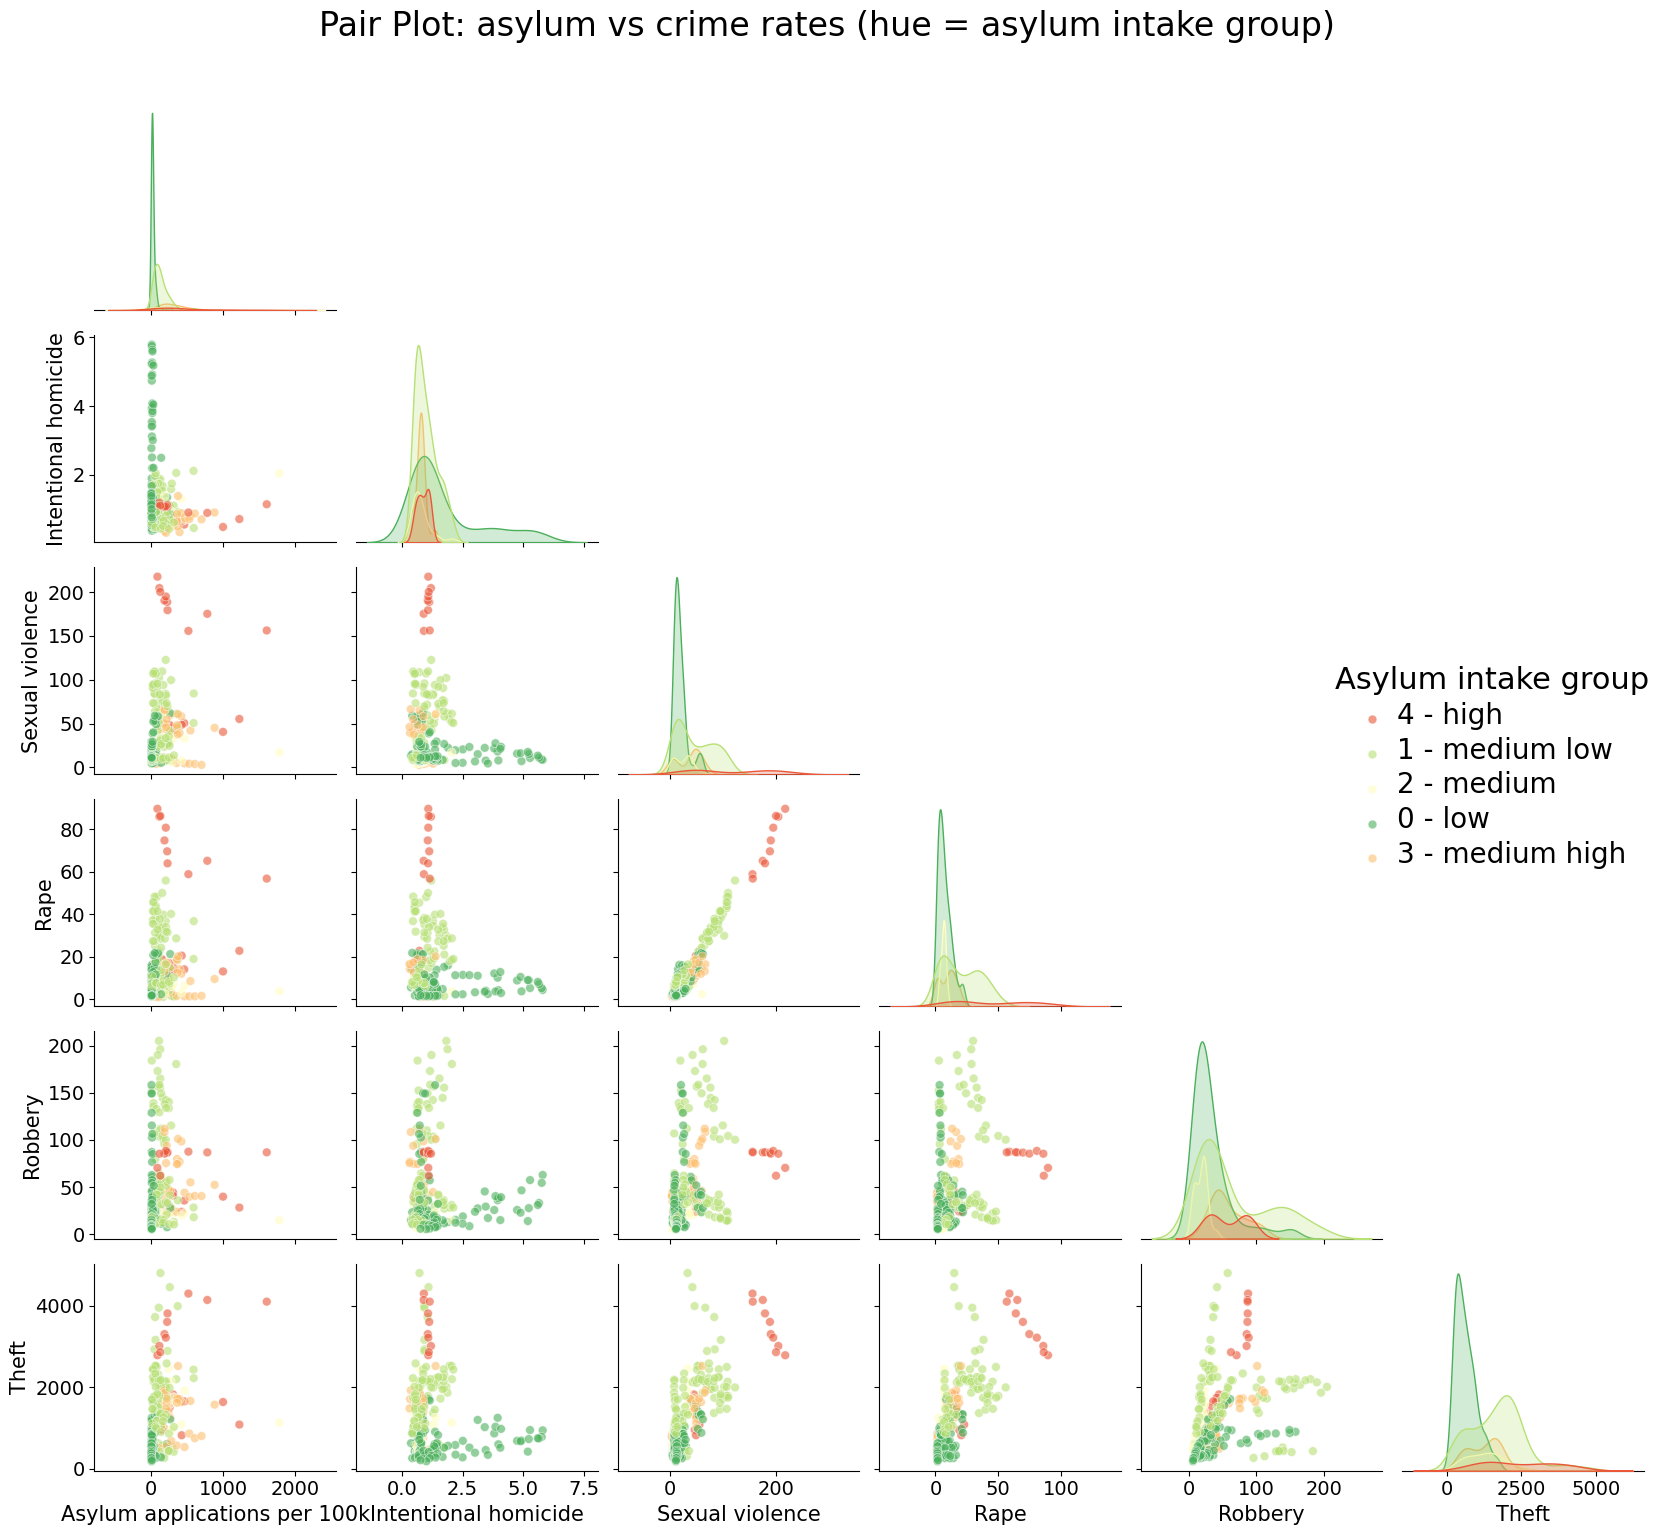

In [ ]:
# 3. Pair Plot of asylum vs crime rates coloured by asylum clusters

# Attach asylum clusters back to the row-level data
crime_cols = list(crime_codes.keys())
cols_to_plot = ['asylum_per_100k'] + crime_cols

df_pairs = df_processed.merge(
    df_cluster[['cluster_asylum', 'cluster_group']],
    left_on='country',
    right_index=True,
    how='left'
)
df_pairs = df_pairs.dropna(subset=['cluster_asylum']).copy()
df_pairs['cluster_asylum'] = df_pairs['cluster_asylum'].astype(int)

# Ensure the label column exists and is ordered (uses existing cluster_group labels)
df_pairs['cluster_group'] = df_pairs['cluster_group']

# Build palette matching the cluster_group labels
label_map_verbose = {
    0: '0 - low',
    1: '1 - medium low',
    2: '2 - medium',
    3: '3 - medium high',
    4: '4 - high',
}
base_palette = sns.color_palette('RdYlGn_r', 5)
cluster_palette = {label_map_verbose[i]: base_palette[i] for i in range(5)}

# Rename columns so axes show descriptive crime names instead of ICCS codes
rename_map = {code: crime_codes.get(code, code) for code in crime_cols}
rename_map['asylum_per_100k'] = 'Asylum applications per 100k'
df_pairs_plot = df_pairs[cols_to_plot + ['cluster_group']].rename(columns=rename_map)

# Create the pair plot with larger text and point size
g = sns.pairplot(
    df_pairs_plot,
    hue='cluster_group',
    palette=cluster_palette,
    corner=True,
    kind='scatter',
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 40}
)

# Enlarge legend text and marker sizes explicitly
if hasattr(g, '_legend') and g._legend is not None:
    leg = g._legend
    leg.set_title('Asylum intake group')
    # Increase title font size
    leg.get_title().set_fontsize(22)
    # Increase label font sizes
    for text in leg.get_texts():
        text.set_fontsize(20)
    # Increase marker (dot) sizes in the legend
    for handle in leg.legendHandles:
        try:
            handle.set_markersize(12)  # adjust this value as needed
        except Exception:
            pass

# Increase axis-label and tick-font sizes (about twice as big)
for ax in g.axes.flatten():
    if ax is not None:
        ax.tick_params(labelsize=14)
        ax.xaxis.label.set_size(15)
        ax.yaxis.label.set_size(15)

g.fig.suptitle('Pair Plot: asylum vs crime rates (hue = asylum intake group)', y=1.02, fontsize=24)
g.fig.tight_layout()
plt.show()